In [1]:
import uproot
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
plt.style.use('belle2')
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
import glob
import os

import joblib

In [2]:
# Function to load and filter data from multiple files
def load_and_filter(file_paths, tree_name, cut_signal):
    branches = ['Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [3]:
# Function to load and filter data from multiple files
def load_and_filter_ds_weight(file_paths, tree_name, cut_signal):
    branches = ['Dp_CMS_cosTheta', 'Pip_cosTheta', 'Pip_p', 'Pip_mcPDG',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal','ds_weight']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [4]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = signal_cut_Dp_pi
cut_signal += ' & Dp_CMS_cosTheta > 0 '

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi_cc/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_pipipi",cut_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_pipipi"
tree_name = "Ks"
BDT_cut = 0.74

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal)

# === Combine data and create labels ===
# variables = ['Pip_cosTheta', 'Pip_p', 'Dp_CMS_cosTheta']
variables = ['Pip_cosTheta', 'Pip_p']

df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_ref)
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_plus.pkl'


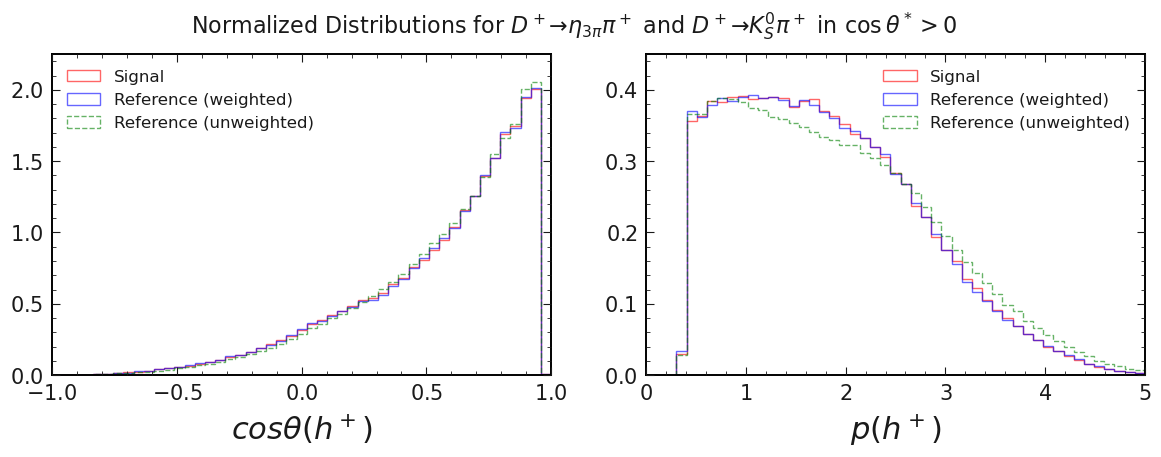

In [5]:

mode = r"$D^+ \to \eta_{3\pi} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"
# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

# fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16)

# plt.tight_layout()

# Set suptitle with adjusted vertical position (lower value = closer to plots)
fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig(f"etapip_pipipi_2_vars_reweighting_plus.pdf")
plt.show()

In [6]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = signal_cut_Dp_pi
cut_signal += ' & Dp_CMS_cosTheta < 0 '

# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi_cc/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_pipipi",cut_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_pipipi"
tree_name = "Ks"
BDT_cut = 0.74

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal)

# === Combine data and create labels ===
# variables = ['Pip_cosTheta', 'Pip_p', 'Dp_CMS_cosTheta']
variables = ['Pip_cosTheta', 'Pip_p']

df_signal['label'] = 1
df_ref['label'] = 0
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_minus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_ref)
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_minus.pkl'


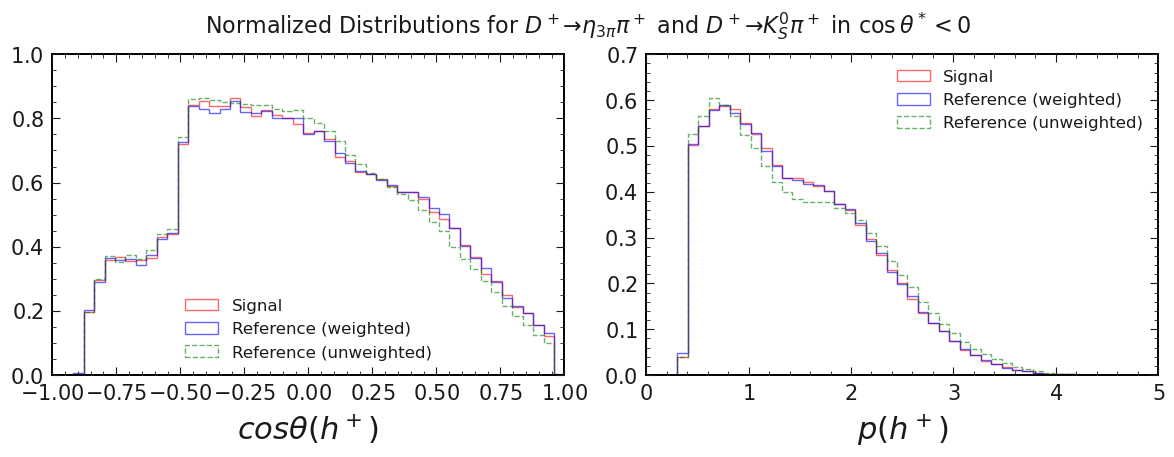

In [7]:

mode = r"$D^+ \to \eta_{3\pi} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"
# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

# fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16)

# plt.tight_layout()

# Set suptitle with adjusted vertical position (lower value = closer to plots)
fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig(f"etapip_pipipi_2_vars_reweighting_minus.pdf")
plt.show()

In [8]:
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = signal_cut_Dp_pi
cut_signal += ' & Dp_CMS_cosTheta > 0 '


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg_cc/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_gg",cut_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg"
tree_name = "Ks"
BDT_cut = 0.83

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_ref)
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_plus.pkl'


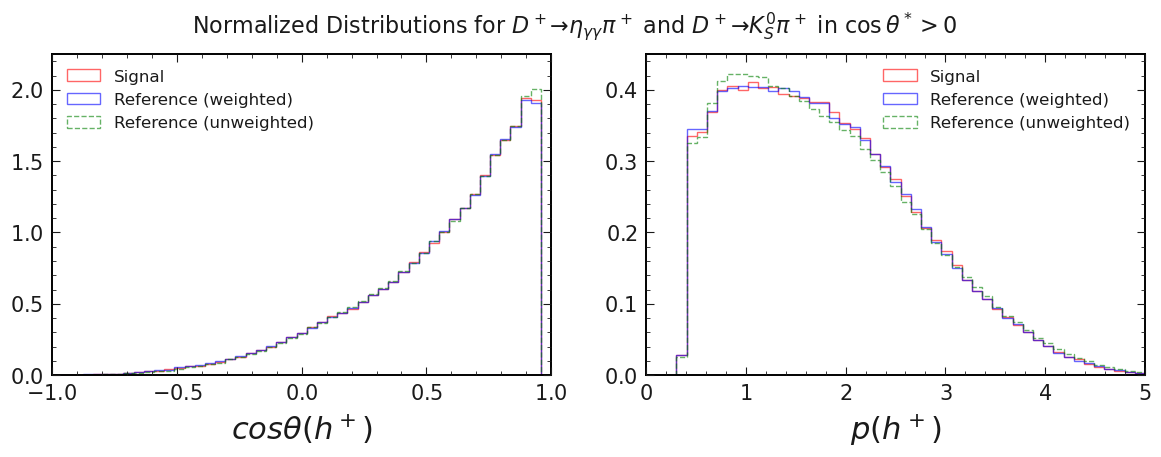

In [9]:

mode = r"$D^+ \to \eta_{\gamma\gamma} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)
    
fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_gg_2_vars_reweighting_plus.pdf")
plt.show()

In [10]:
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal = signal_cut_Dp_pi
cut_signal += ' & Dp_CMS_cosTheta < 0 '


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg_cc/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter(signal_pattern, "etapip_gg",cut_signal)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg"
tree_name = "Ks"
BDT_cut = 0.83

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal)

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0

# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_{ref_tree}_minus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_ref)
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_minus.pkl'


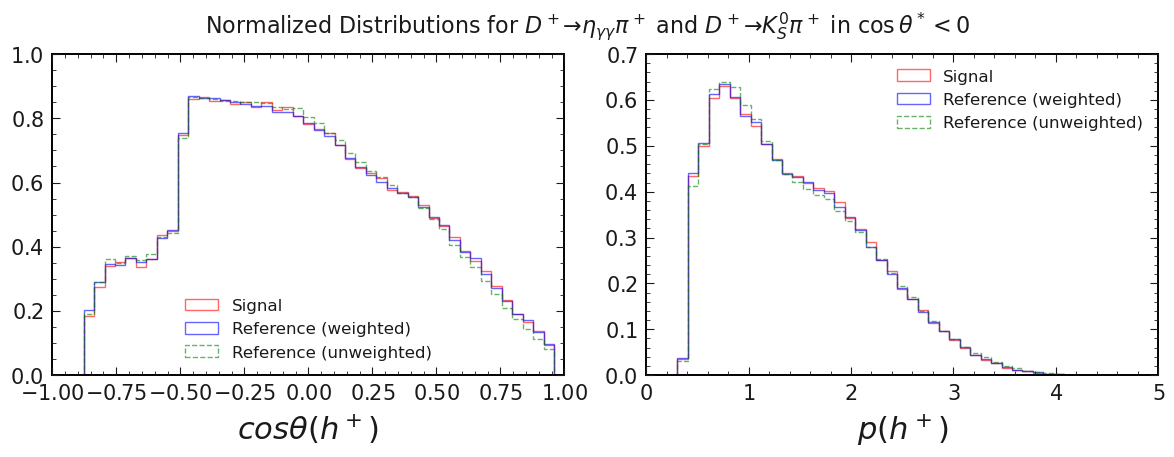

In [11]:

mode = r"$D^+ \to \eta_{\gamma\gamma} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal',color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_ref['weight'], label='Reference (weighted)',color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--',color='green')
    # axes[idx].set_title(f'Normalized Distribution')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)
    
fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"etapip_gg_2_vars_reweighting_minus.pdf")
plt.show()

In [4]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_pi
cut_signal_Dsp = signal_cut_Dp_pi

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 '
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 '


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_pipipi/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_pipipi_cc/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_pipipi", cut_signal_Dp)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_pipipi"
tree_name = "Ks"
BDT_cut = 0.74

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal_Dsp)
df_ref['ds_weight'] = 1.0  # ✅  weight 추가

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total


/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_pipipi_plus.pkl'


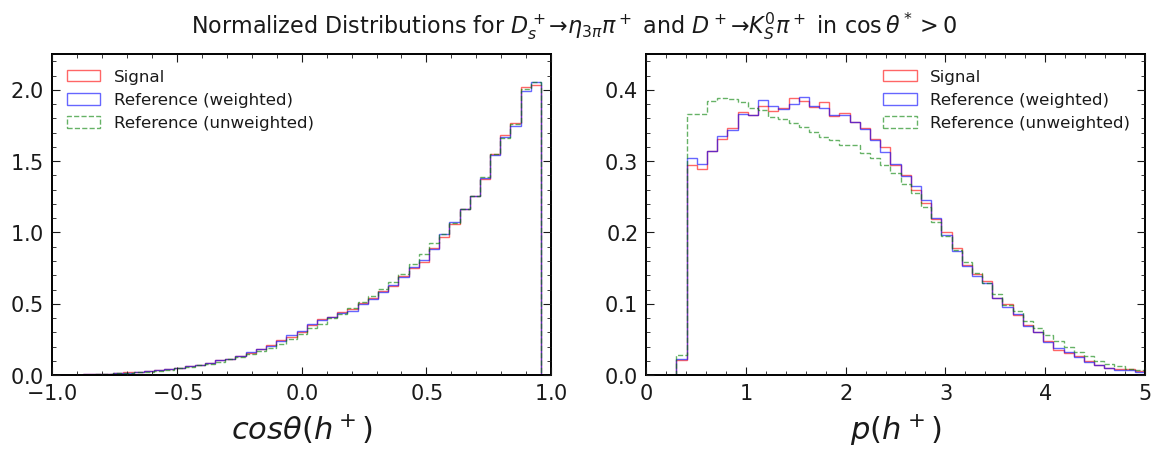

In [5]:

mode = r"$D^+_s \to \eta_{3\pi} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_pipipi_2_vars_reweighting_plus.pdf")
plt.show()

In [6]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_pi
cut_signal_Dsp = signal_cut_Dp_pi

cut_signal_Dp += ' & Dp_CMS_cosTheta < 0 '
cut_signal_Dsp += ' & Dp_CMS_cosTheta < 0 '


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_pipipi/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_pipipi_cc/250216_loose_v7/etapip_pipipi/min_unc_search/new_Ds_v2/0.74/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_pipipi", cut_signal_Dp)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_pipipi"
tree_name = "Ks"
BDT_cut = 0.74

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal_Dsp)
df_ref['ds_weight'] = 1.0  # ✅  weight 추가

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_minus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total


/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_pipipi_minus.pkl'


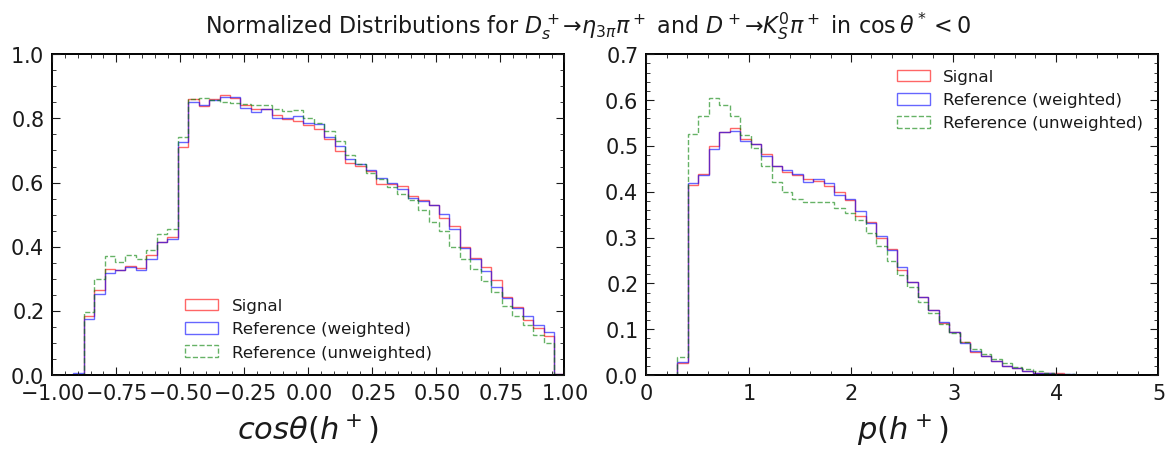

In [7]:

mode = r"$D^+_s \to \eta_{3\pi} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_pipipi_2_vars_reweighting_minus.pdf")
plt.show()

In [10]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_pi
cut_signal_Dsp = signal_cut_Dp_pi

cut_signal_Dp += ' & Dp_CMS_cosTheta > 0 '
cut_signal_Dsp += ' & Dp_CMS_cosTheta > 0 '
# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg_cc/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg", cut_signal_Dp)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg"
tree_name = "Ks"
BDT_cut = 0.83

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal_Dsp)
df_ref['ds_weight'] = 1.0  # ✅  weight 추가

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_plus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_plus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_gg_plus.pkl'


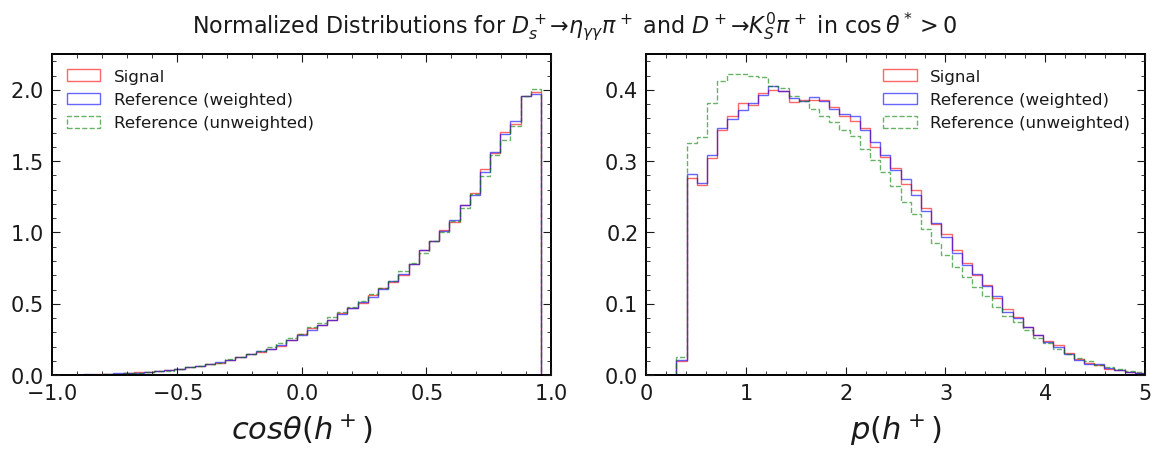

In [11]:

mode = r"$D^+_s \to \eta_{\gamma\gamma} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'upper left',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*>0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_gg_2_vars_reweighting_plus.pdf")
plt.show()

In [12]:

signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"


cut_signal_Dp = signal_cut_Dsp_pi
cut_signal_Dsp = signal_cut_Dp_pi

cut_signal_Dp += ' & Dp_CMS_cosTheta < 0 '
cut_signal_Dsp += ' & Dp_CMS_cosTheta < 0 '
# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/weighted/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dsptoetapip_gg_cc/250216_loose_v7/etapip_gg/min_unc_search/new_Ds_v2/0.83/weighted/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal = load_and_filter_ds_weight(signal_pattern, "etapip_gg", cut_signal_Dp)

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p_v3"
cm_elements = [
    "MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1",
    "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1",
    "MCrd_Ks_mori_off_v1"
]
ref_tree = "etapip_gg"
tree_name = "Ks"
BDT_cut = 0.83

file_list_ref = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/{BDT_cut}/*.BCS.root"
    file_list_ref += glob.glob(pattern)

df_ref = load_and_filter(file_list_ref, "Ks",cut_signal_Dsp)
df_ref['ds_weight'] = 1.0  # ✅  weight 추가

# === Combine data and create labels ===
variables = ['Pip_cosTheta', 'Pip_p']
df_signal['label'] = 1
df_ref['label'] = 0
# === Balance datasets ===
n_signal = len(df_signal)
n_ref = len(df_ref)

n_min = min(n_signal, n_ref)

# Sample equal number of events from each
balanced_signal = df_signal.sample(n=n_min, random_state=42)
balanced_ref = df_ref.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal, balanced_ref], ignore_index=True)
# combined_df = pd.concat([df_signal, df_ref], ignore_index=True)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    combined_df[variables], combined_df['label'], combined_df['ds_weight'],
    test_size=0.3, random_state=42
)

# model = xgb.XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.1,
#     subsample=0.8, use_label_encoder=False, eval_metric='logloss'
# )
model = xgb.XGBClassifier(
use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train, sample_weight=w_train)


# === Save model using joblib ===
joblib.dump(model, f"xgb_model_Ds_{ref_tree}_minus.pkl")
print(f"✅ Model saved to 'xgb_model_Ds_{ref_tree}_minus.pkl'")

# === Predict and reweight ===
proba_ref = model.predict_proba(df_ref[variables])[:, 1]
df_ref['weight'] = proba_ref / (1 - proba_ref + 1e-6)

target_total = df_ref['ds_weight'].sum()
actual_total = df_ref['weight'].sum()
df_ref['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_Ds_etapip_gg_minus.pkl'


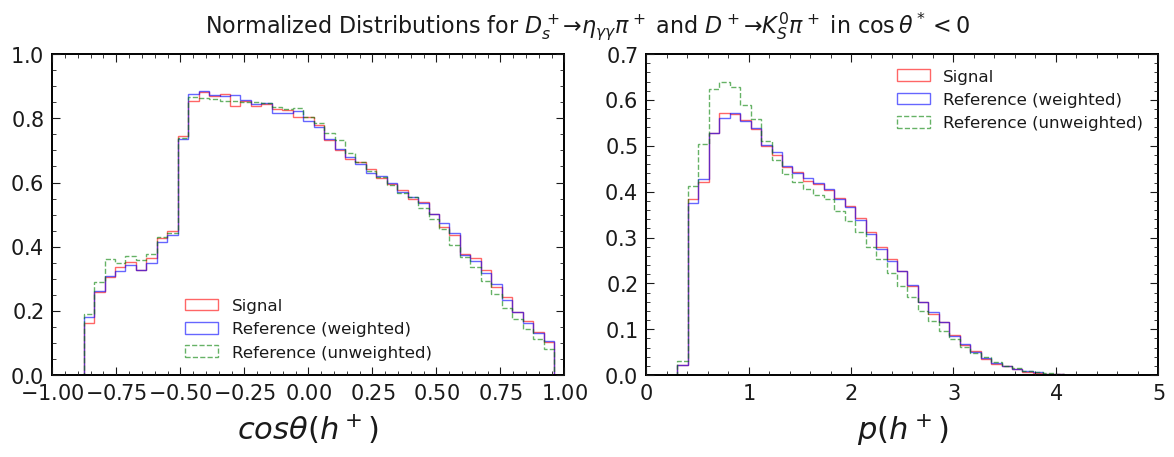

In [13]:

mode = r"$D^+_s \to \eta_{\gamma\gamma} \pi^+$"
ref_mode = r"$D^+ \to K_S^0 \pi^+$"

# === Plot distributions ===
bins_dict = {
    'Pip_cosTheta': np.linspace(-1, 1, 50),
    'Pip_p': np.linspace(0, 5, 50),
    # 'Dp_CMS_cosTheta': np.linspace(-1, 1, 50)
}

legend_loc = {
    'Pip_cosTheta': 'lower center',
    'Pip_p': 'upper right',
    # 'Dp_CMS_cosTheta': 'lower center',
}
var_info = {
    'Pip_cosTheta': r'$cos\theta(h^+)$',
    'Pip_p': r'$p(h^+)$',
    # 'Dp_CMS_cosTheta': r'$cos\theta^* (D^+_{(s)})$',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal['ds_weight'], label='Signal', color='red')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_ref['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_ref[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', linestyle='--', color='green')
    # axes[idx].set_title(f'{mode}')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var],fontsize=12)

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode} in $\cos\theta^*<0$', fontsize=16, y=0.92)
plt.tight_layout()

plt.savefig(f"Ds_etapip_gg_2_vars_reweighting_minus.pdf")
plt.show()